# Calibration Analysis

## Goal
Quantify how well Polymarket prices track real-world resolution rates, 
and identify where (and how badly) miscalibration appears.

## Filtering
- Volume ≥ $100 (removes ~30% of markets)
- Markets priced at exactly 0 or 1 excluded (would break log loss)
- 1-day-before-resolution price used as the calibration target; 1-month horizon dropped 
  due to insufficient sample (only 90 markets had ≥30-day lifetimes, 79% with zero price change)

## Methods
- 10 equal-width bins on predicted probability, empirical YES rate per bin
- Wilson confidence intervals for per-bin uncertainty
- Brier score and log loss, overall and per-category
- Per-category breakdown to identify where miscalibration concentrates

In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv("resolved_markets.csv")

In [18]:
df['price_1d'] = df['last_trade_price'] - df['one_day_price_change']
df['price_1w'] = df['last_trade_price'] - df['one_week_price_change']
df['price_1m'] = df['last_trade_price'] - df['one_month_price_change']

In [19]:
df[['price_1d', 'price_1w', 'price_1m']].describe()

,price_1d,price_1w,price_1m
count,5076.000000,5076.000000,5076.000000
mean,0.404103,0.415108,0.402320
std,0.399204,0.446665,0.467231
min,-0.962000,-0.509500,-0.001000
25%,0.010000,0.001000,0.001000
50%,0.370250,0.160000,0.030000
75%,0.760750,0.990000,0.990000
max,1.879500,1.224500,0.999000


In [20]:
# How many markets are out of range at each horizon?
for col in ['price_1d', 'price_1w', 'price_1m']:
    bad = ((df[col] < 0) | (df[col] > 1)).sum()
    pct = bad / len(df) * 100
    print(f"{col}: {bad} out of range ({pct:.1f}%)")

# Look at a handful of bad rows to see what's going on
df[(df['price_1d'] < 0) | (df['price_1d'] > 1)][
    ['question', 'category', 'volume', 'last_trade_price', 'one_day_price_change', 'price_1d']
].head(10)

price_1d: 123 out of range (2.4%)
price_1w: 13 out of range (0.3%)
price_1m: 1 out of range (0.0%)


,question,category,volume,last_trade_price,one_day_price_change,price_1d
175,Game 2: Both Teams Slay a Dragon?,Sports,0.000000,0.000,0.4995,-0.4995
177,Game 2: Any Player Quadra Kill?,Sports,0.000000,0.000,0.4995,-0.4995
178,Game 2: Any Player Penta Kill?,Sports,0.000000,0.000,0.9620,-0.9620
190,First Blood in Game 2?,Sports,0.000000,0.000,0.4995,-0.4995
232,Counter-Strike: tincan vs JUMBO TEAM (BO1) - E...,Sports,5.530000,0.000,0.4995,-0.4995
284,Will Iran take military action against a Gulf ...,Geopolitics,31284.386921,0.999,-0.1415,1.1405
471,Mobile Legends Bang Bang: Geek Fam ID vs Natus...,Sports,1021.880359,0.690,-0.6045,1.2945
473,Games Total: O/U 2.5,Sports,63.781576,0.570,-0.4895,1.0595
657,Set 1 Winner: Feldbausch vs Tabur,Sports,182.980000,0.610,-0.4795,1.0895
826,Map 1: Odd/Even Total Rounds?,Sports,0.000000,0.000,0.4945,-0.4945


In [21]:
# 1. Market lifetime distribution
df['created_at'] = pd.to_datetime(df['created_at'], format='ISO8601')
df['closed_time'] = pd.to_datetime(df['closed_time'], format='ISO8601')
df['lifetime_days'] = (df['closed_time'] - df['created_at']).dt.days
print(df['lifetime_days'].describe())
print(f"\nMarkets with lifetime >= 30 days: {(df['lifetime_days'] >= 30).sum()}")
print(f"Markets with lifetime >= 7 days: {(df['lifetime_days'] >= 7).sum()}")

count    5076.000000
mean        5.604216
std        18.432707
min         0.000000
25%         0.000000
50%         1.000000
75%         4.000000
max       196.000000
Name: lifetime_days, dtype: float64

Markets with lifetime >= 30 days: 176
Markets with lifetime >= 7 days: 1076


In [22]:
# 2. Within markets that EXISTED long enough, recount zeros
for col, days in [('one_day_price_change', 1), ('one_week_price_change', 7), ('one_month_price_change', 30)]:
    eligible = df[(df['lifetime_days'] >= days) & (df['volume'] >= 100)]
    n_zero = (eligible[col] == 0).sum()
    print(f"{col}: {len(eligible)} eligible, {n_zero} ({100*n_zero/len(eligible):.1f}%) zero")

one_day_price_change: 2448 eligible, 244 (10.0%) zero
one_week_price_change: 828 eligible, 196 (23.7%) zero
one_month_price_change: 90 eligible, 71 (78.9%) zero


In [23]:
eligible = df[(df['lifetime_days'] >= 1) & (df['volume'] >= 100)]
for low, high in [(100, 1000), (1000, 10000), (10000, float('inf'))]:
    n = ((eligible['volume'] >= low) & (eligible['volume'] < high)).sum()
    print(f"${low:,}–${high if high != float('inf') else '∞'}: {n} markets")

$100–$1000: 872 markets
$1,000–$10000: 956 markets
$10,000–$∞: 620 markets


In [25]:
df['prev_day_price'] = df['last_trade_price'] - df['one_day_price_change']
eligible = df[(df['lifetime_days'] >= 1) & (df['volume'] >= 100) & (df['prev_day_price'] > 0) & (df['prev_day_price'] < 1)].copy()

In [26]:
bin_edges = np.linspace(0, 1, 11)
eligible['bin'] = pd.cut(eligible['prev_day_price'], bins = bin_edges, include_lowest=True)

In [28]:
calibration = eligible.groupby('bin', observed = True).agg(
    empirical_rate = ('yes_resolved', 'mean'),
    n = ('yes_resolved', 'size'),
    x = ('prev_day_price', 'mean')
).reset_index()

print(calibration)

             bin  empirical_rate    n         x
0  (-0.001, 0.1]        0.011511  695  0.016925
1     (0.1, 0.2]        0.188406  138  0.150058
2     (0.2, 0.3]        0.237762  143  0.258248
3     (0.3, 0.4]        0.274882  211  0.345818
4     (0.4, 0.5]        0.558313  403  0.475192
5     (0.5, 0.6]        0.531680  363  0.529393
6     (0.6, 0.7]        0.500000  120  0.648342
7     (0.7, 0.8]        0.663043   92  0.748924
8     (0.8, 0.9]        0.507463   67  0.849276
9     (0.9, 1.0]        0.837398  123  0.976638


In [35]:
from statsmodels.stats.proportion import proportion_confint

counts = np.round(calibration['empirical_rate'] * calibration['n']).astype(int)

lower, upper = proportion_confint(counts, calibration['n'], method='wilson')
calibration['ci_lower'] = lower
calibration['ci_upper'] = upper
print(calibration)

             bin  empirical_rate    n         x  ci_lower  ci_upper
0  (-0.001, 0.1]        0.011511  695  0.016925  0.005844  0.022548
1     (0.1, 0.2]        0.188406  138  0.150058  0.131942  0.261748
2     (0.2, 0.3]        0.237762  143  0.258248  0.175426  0.313819
3     (0.3, 0.4]        0.274882  211  0.345818  0.219072  0.338741
4     (0.4, 0.5]        0.558313  403  0.475192  0.509505  0.606019
5     (0.5, 0.6]        0.531680  363  0.529393  0.480285  0.582413
6     (0.6, 0.7]        0.500000  120  0.648342  0.411939  0.588061
7     (0.7, 0.8]        0.663043   92  0.748924  0.561653  0.751364
8     (0.8, 0.9]        0.507463   67  0.849276  0.390638  0.623478
9     (0.9, 1.0]        0.837398  123  0.976638  0.762156  0.892204


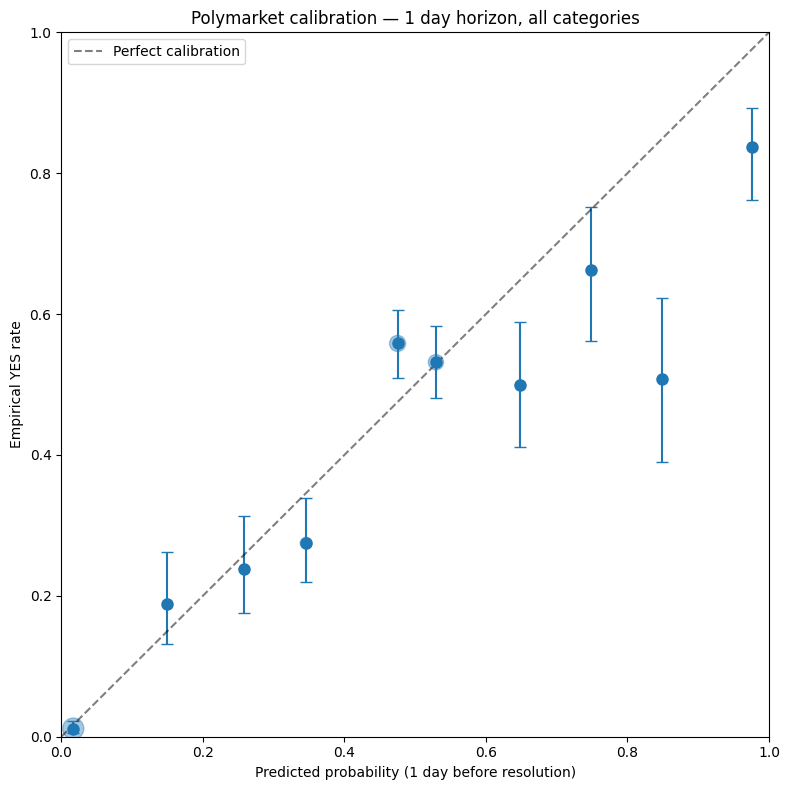

In [36]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))

ax.errorbar(calibration['x'], calibration['empirical_rate'],
            yerr=[calibration['empirical_rate'] - calibration['ci_lower'], calibration['ci_upper'] - calibration['empirical_rate']],
            fmt='o', capsize=4, markersize=8)

ax.scatter(calibration['x'], calibration['empirical_rate'],
           s=calibration['n'] / 3, alpha=0.4)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
ax.set_xlabel('Predicted probability (1 day before resolution)')
ax.set_ylabel('Empirical YES rate')
ax.set_title('Polymarket calibration — 1 day horizon, all categories')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
from sklearn.metrics import brier_score_loss, log_loss

p = eligible['prev_day_price']
y = eligible['yes_resolved']
print(f"Brier: {brier_score_loss(y, p):.4f}")
print(f"Log loss: {log_loss(y, p):.4f}")

Brier: 0.1622
Log loss: 0.4726


In [38]:
print(f"{'Category':<20} {'n':>5}  {'Brier':>7}  {'LogLoss':>8}")
for cat in eligible['category'].value_counts().index:
    sub = eligible[eligible['category'] == cat]
    if len(sub) < 30: continue
    brier = brier_score_loss(sub['yes_resolved'], sub['prev_day_price'])
    ll = log_loss(sub['yes_resolved'], sub['prev_day_price'])
    print(f"{cat:<20} {len(sub):>5}  {brier:.4f}   {ll:.4f}")

Category                 n    Brier   LogLoss
Sports                 914  0.2361   0.6830
Crypto                 551  0.2045   0.5758
Weather                532  0.0436   0.1490
Finance                134  0.1679   0.4938
Politics               113  0.0538   0.1663
Other                   56  0.0102   0.0411
Geopolitics             55  0.0192   0.0905


In [39]:
results = []
for cat in eligible['category'].value_counts().index:
    sub = eligible[eligible['category'] == cat].copy()
    if len(sub) < 100: continue
    sub['bin'] = pd.cut(sub['prev_day_price'], bins=bin_edges, include_lowest=True)
    cat_cal = sub.groupby('bin', observed=True).agg(
        empirical_rate=('yes_resolved', 'mean'),
        n=('yes_resolved', 'size'),
        x=('prev_day_price', 'mean')
    ).reset_index()
    cat_cal['category'] = cat
    results.append(cat_cal)
cal_by_cat = pd.concat(results, ignore_index=True)
print(cal_by_cat)

              bin  empirical_rate    n         x  category
0   (-0.001, 0.1]        0.026667   75  0.034740    Sports
1      (0.1, 0.2]        0.271186   59  0.150932    Sports
2      (0.2, 0.3]        0.289157   83  0.264470    Sports
3      (0.3, 0.4]        0.311594  138  0.346855    Sports
4      (0.4, 0.5]        0.517766  197  0.466063    Sports
5      (0.5, 0.6]        0.519737  152  0.535918    Sports
6      (0.6, 0.7]        0.434783   69  0.646312    Sports
7      (0.7, 0.8]        0.642857   56  0.747054    Sports
8      (0.8, 0.9]        0.351351   37  0.849338    Sports
9      (0.9, 1.0]        0.604167   48  0.973229    Sports
10  (-0.001, 0.1]        0.000000   55  0.018036    Crypto
11     (0.1, 0.2]        0.000000   13  0.159654    Crypto
12     (0.2, 0.3]        0.000000    5  0.258900    Crypto
13     (0.3, 0.4]        0.150000   20  0.351025    Crypto
14     (0.4, 0.5]        0.606061  165  0.487312    Crypto
15     (0.5, 0.6]        0.515789  190  0.522108    Cryp

## Analysis — 1-day horizon

- Overall: Brier 0.162, log loss 0.473. Beats "always predict base rate"
  (Brier 0.224) by ~28%, so markets do contain real info.
- Category does most of the work here. Weather, Politics, Geopolitics, and
  Other are essentially perfectly calibrated (Brier 0.02–0.05). Sports
  (n=914, Brier 0.236) and Crypto (n=551, Brier 0.205) drag the average down.
- Sports favorites are systematically overpriced. Markets priced at 80–98%
  YES only resolve YES 35–60% of the time — this is the mispricing signal
  Day 3 will target.
- Smaller counter-pattern at p ≈ 0.48: slight underconfidence (predicted 0.48,
  actual 0.56, n=403). Real, but a smaller effect than the Sports overconfidence.
- Limitations: dropped 1-month horizon (only 90 eligible markets, 79% with
  zero price change). Categories like Weather/Politics look "well-calibrated"
  partly because their markets cluster at extreme prices and are easy.